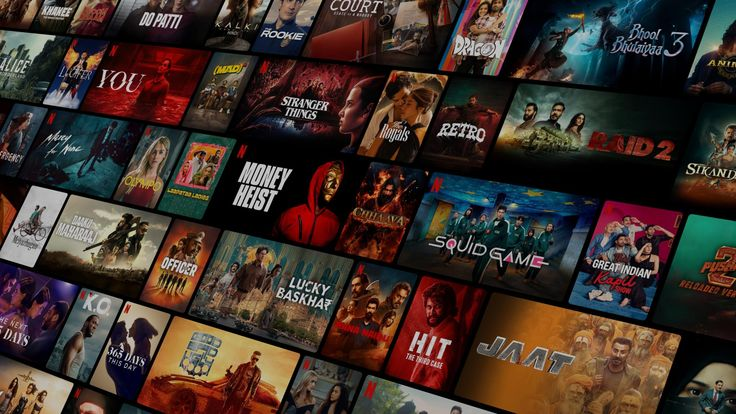

## Can a machine predict how much a user will enjoy a movie - before they watch it?

We use the MovieLens 100K dataset:
- 943 users
- 1,682 movies
- 100,000 ratings (scale: 1 to 5 stars)

Goal: Build a model that takes a (user, movie) pair
and predicts the rating accurately.

This is a REGRESSION problem - we predict a number,
not a category.



## Import libraries


In [8]:
# Every ML project starts by importing tools. Think of this like opening your toolbox before starting work.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [9]:
# We load the MovieLens 100K file. It has no header row, so we give the columns names ourselves. Each row = one user rating one movie.
cols =["User_id", "Movie_id", "Rating", "Timestamp"]
df = pd.read_csv("u.data", sep = "\t", names = cols)
df.head()

,User_id,Movie_id,Rating,Timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


#### Before any modelling, we check: are there missing values? What does the data look like? This is called a sanity check.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   User_id    100000 non-null  int64
 1   Movie_id   100000 non-null  int64
 2   Rating     100000 non-null  int64
 3   Timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [11]:
df.shape

(100000, 4)

In [12]:
# checking Null Values
df.isnull().sum()  # no Null values

User_id      0
Movie_id     0
Rating       0
Timestamp    0
dtype: int64

- The dataset has 100,000 rows. Each row tells us which user rated which movie and what score they gave. There are no missing values.

In [13]:
df["Rating"].describe()

count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: Rating, dtype: float64

## Visualization

In [14]:
df['Rating'].value_counts().sort_index()

Rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64

In [15]:
df.groupby("User_id")["Rating"].count()

User_id
1      272
2       62
3       54
4       24
5      175
      ... 
939     49
940    107
941     22
942     79
943    168
Name: Rating, Length: 943, dtype: int64

In [16]:
df.groupby("Movie_id")["Rating"].count()

Movie_id
1       452
2       131
3        90
4       209
5        86
       ... 
1678      1
1679      1
1680      1
1681      1
1682      1
Name: Rating, Length: 1682, dtype: int64

#### We plot 3 charts: how ratings are distributed, how many ratings each user gave, and how many ratings each movie got. This tells us if the data is balanced or skewed.

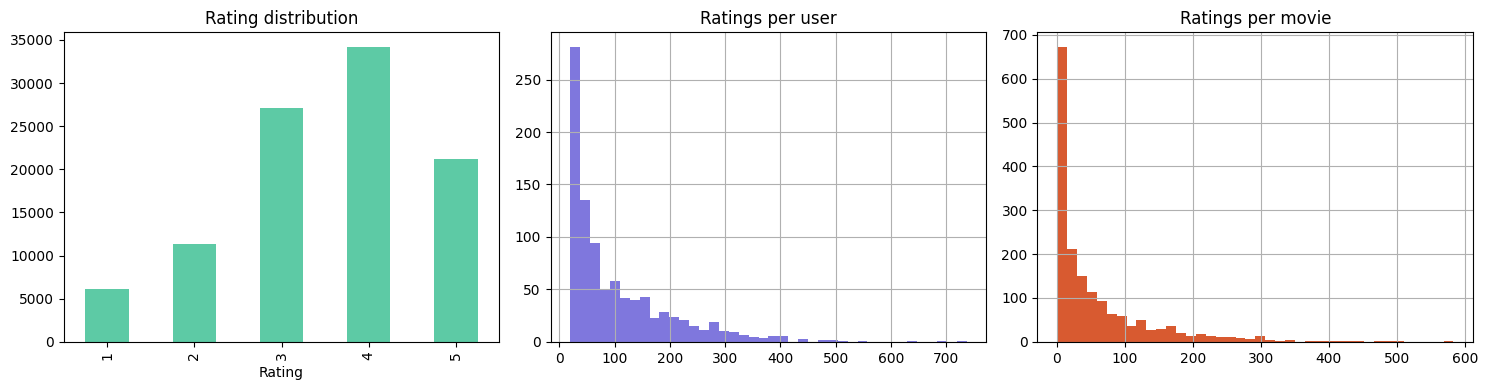

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Rating distribution
df["Rating"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0], color="#5DCAA5")
axes[0].set_title("Rating distribution")

# Ratings per user
df.groupby("User_id")["Rating"].count().hist(
    bins=40, ax=axes[1], color="#7F77DD")
axes[1].set_title("Ratings per user")

# Ratings per movie
df.groupby("Movie_id")["Rating"].count().hist(
    bins=40, ax=axes[2], color="#D85A30")
axes[2].set_title("Ratings per movie")

plt.tight_layout()
plt.show()

- EDA showed that most users rated between 20 and 100 movies, and most popular movies had many ratings while niche movies had very few. Ratings leaned towards 3 and 4 stars - users generally rated things they chose to watch positively.

#### Raw user IDs and movie IDs mean nothing to a model. So we create meaningful numbers from them — like "what is this user's average rating?" and "how popular is this movie?". This is called feature engineering.

In [18]:
# Feature Engineering
from sklearn.preprocessing import LabelEncodAAer

# Encode IDs
df["User_enc"] = LabelEncoder().fit_transform(df["User_id"])
df["movie_enc"] = LabelEncoder().fit_transform(df["Movie_id"])

# User Features: How Generous is this user on Average?
u_stats = df.groupby("User_enc")["Rating"].agg(
    user_mean ="mean",user_std ="std",user_count ="count"
)

# Movie Features: How good is this movie on Average?
m_stats = df.groupby("movie_enc")["Rating"].agg(
    movie_mean ="mean",movie_std ="std",movie_count ="count"
)

In [19]:
df = df.merge(u_stats,on="User_enc").merge(m_stats,on="movie_enc")
df["global_mean"]=df["Rating"].mean()
df.fillna(0,inplace=True)

- I engineered 9 features - user average rating, user rating count, user standard deviation, the same 3 for movies, encoded IDs, and global mean. These capture user behaviour and movie quality in a way the model can learn from.

In [20]:
df

,User_id,Movie_id,Rating,Timestamp,User_enc,movie_enc,user_mean,user_std,user_count,movie_mean,movie_std,movie_count,global_mean
0,196,242,3,881250949,195,241,3.615385,1.016065,39,3.991453,0.995643,117,3.52986
1,186,302,3,891717742,185,301,3.413043,1.223867,92,4.161616,0.854721,297,3.52986
2,22,377,1,878887116,21,376,3.351562,1.493239,128,2.153846,1.068188,13,3.52986
3,244,51,2,880606923,243,50,3.651261,1.071406,238,3.456790,1.162426,81,3.52986
4,166,346,1,886397596,165,345,3.550000,1.431782,20,3.642857,1.084172,126,3.52986
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,880,476,3,880175444,879,475,3.426630,0.982156,368,3.018750,1.101582,160,3.52986
99996,716,204,5,879795543,715,203,3.888476,1.041408,269,3.834286,0.912173,350,3.52986
99997,276,1090,1,874795795,275,1089,3.465251,1.017140,518,2.405405,1.189292,37,3.52986
99998,13,225,2,882399156,12,224,3.097484,1.416414,636,2.908257,1.076184,109,3.52986


#### We check if any features are too strongly related to each other. If two features are almost identical, one is redundant. This is called checking for multicollinearity.

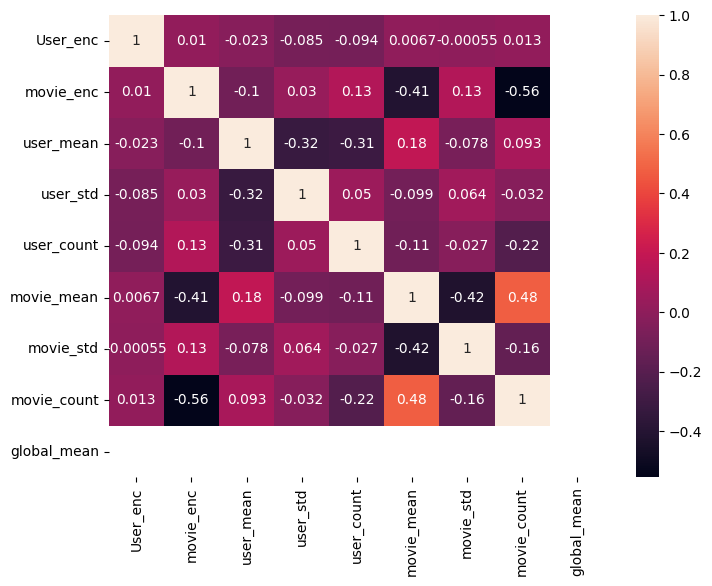

In [62]:
# correlation 
import seaborn as sns
features = ["user_enc", "movie_enc", "user_mean", "user_std",
            "user_count", "movie_mean", "movie_std",
            "movie_count", "global_mean"]
plt.figure(figsize=(8,6))
sns.heatmap(df[features].corr(),annot=True)
plt.show()

#### The heatmap showed no correlation above 0.7 between any two features, which means there is no multicollinearity. All 9 features carry unique information so I kept them all.
• No strong correlations (> |0.7|) were observed, indicating low multicollinearity.

• movie_mean and movie_count show a moderate positive correlation (0.48).

• movie_mean and movie_std exhibit a moderate negative correlation (−0.42).

• User-related features have relatively weak correlations with each other.

• Encoded IDs have minimal correlation with engineered statistical features.

• Overall, the feature set appears well-balanced and suitable for model training.

## Train & Test Split
 We split data into 80% for training and 20% for testing. The model never sees the test set during training. This is how we honestly measure if the model actually learned or just memorised.

In [63]:
from sklearn.model_selection import train_test_split
features = ["User_enc","movie_enc","user_mean","user_std",
            "user_count","movie_mean","movie_std","movie_count","global_mean"]

X =df[features]
y = df["Rating"]
X_train,X_test,y_train,y_test =train_test_split(
    X,y,test_size=0.2,random_state =42
)

print(f"Train:{len(X_train):,} | Test:{len(X_test):,}")

Train:80,000 | Test:20,000


#### We train 6 different models on the same data and measure their error. RMSE tells us on average how many stars we are off by. Lower RMSE = better model.

In [42]:

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
import xgboost as xgb

# One helper function trains any model, evaluates it, and returns RMSE + MAE. Then we run all 6.
def evaluate(name,model):
    model.fit(X_train, y_train)
    preds =np.clip(model.predict(X_test),1,5)
    rmse =np.sqrt(mean_squared_error(y_test,preds))
    mae =mean_absolute_error(y_test,preds)
    print(f"{name:<28} RMSE={rmse:4f} MAE ={mae:4f}")
    return{"name":name,"rmse":rmse,"mae":mae,"model":model}

results =[
    evaluate("Linear Regression", LinearRegression()),
    evaluate("Ridge Regression", Ridge(alpha=1.0)),
    evaluate("Decision Tree", DecisionTreeRegressor( max_depth=8,random_state=42)),
    evaluate("Random Forest", RandomForestRegressor(n_estimators=100,n_jobs =-1,random_state =42)),
    evaluate("Gradient Boosting", GradientBoostingRegressor(n_estimators=150,random_state=42)),
    evaluate("XGBoost", xgb.XGBRegressor(n_estimators=200,learning_rate =0.05,verbosity=0,random_state=42)),]

Linear Regression            RMSE=0.928519 MAE =0.734404
Ridge Regression             RMSE=0.928519 MAE =0.734405
Decision Tree                RMSE=0.932170 MAE =0.733528
Random Forest                RMSE=0.935872 MAE =0.732617
Gradient Boosting            RMSE=0.919423 MAE =0.726092
XGBoost                      RMSE=0.912643 MAE =0.718017


- trained 6 baseline models - from simple linear regression to ensemble methods like XGBoost. I used a single evaluate function so every model is tested fairly on the same 20,000 test rows

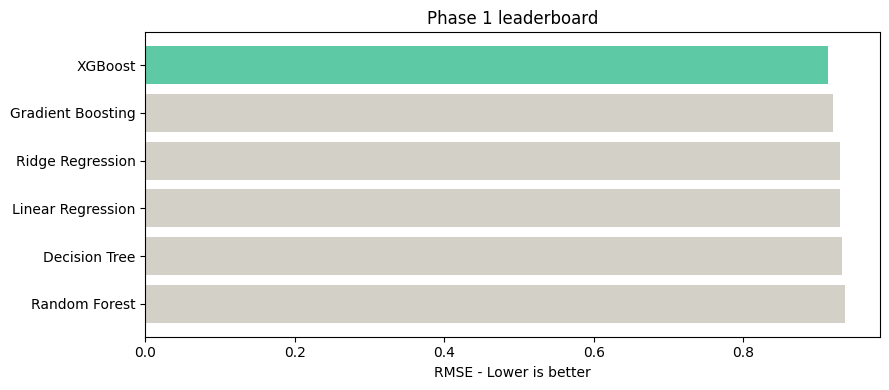

Winner:XGBoost RMSE =0.9126


In [47]:

# Sort by RMSE (lower = better). Plot a bar chart to clearly visualise the leaderboard.

results_df =pd.DataFrame([{"model":r["name"],"rmse":r["rmse"],"mae":r["mae"]}
                         for r in results]).sort_values("rmse")

colors = ["#5DCAA5" if i ==0 else "#D3D1C7" for i in range(len(results_df))]

fig,ax = plt.subplots(figsize=(9,4))
ax.barh(results_df["model"],results_df["rmse"],color =colors)
ax.invert_yaxis()
ax.set_xlabel("RMSE - Lower is better")
ax.set_title("Phase 1 leaderboard")
plt.tight_layout()
plt.show()

best = results_df.iloc[0]
print(f"Winner:{best['model']} RMSE ={best['rmse']:.4f}")

In [50]:
best_model = xgb.XGBRegressor(n_estimators=200,learning_rate=0.05,verbosity=0,random_state=42)
best_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [52]:
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Train RMSE:", train_rmse)
print("Test RMSE :", test_rmse)

Train RMSE: 0.8831666219288596
Test RMSE : 0.9126515380236164


Feature engineering successfully transformed raw user and movie IDs into meaningful predictive features. Correlation analysis revealed no severe multicollinearity among the features. Among six evaluated models, XGBoost achieved the best performance with the lowest RMSE (0.9126) and MAE (0.7180), making it the most effective model for movie rating prediction on the MovieLens 100K dataset. The results show that boosting-based approaches outperform traditional linear and tree-based models for this task.